# Generate Representations
In this notebook, we generate the inputs for the machine learning model. At the end of this notebook, we will have computed the features for all available data, and generated the pickle files needed to run these models for any available data.

In [1]:
%matplotlib inline
import sys
import math
sys.path.append("../")
from matplotlib import pyplot as plt
from stopping_power_ml.features import LocalChargeDensity, ProjectedAGNIFingerprints, IonIonForce, ProjectileVelocity, ProjectileDisplacement, PositionOffset, ClosestAtomsDistances
from stopping_power_ml.utils.io import get_charge_density_interpolator
from matminer.featurizers.base import MultipleFeaturizer
from tqdm import tqdm_notebook as tqdm
from glob import glob
import pickle as pkl
from fractions import Fraction
import pandas as pd
import numpy as np
import gzip
import os
import time
import uuid
from tqdm.notebook import tqdm

/u/saltsj/.local/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Configure Parsl

## Load in Dataset
Load in the pickled dataset from `parse-qbox-data`

In [2]:
data = pkl.load(gzip.open('data.pkl.gz', 'rb'))
print('Loaded %d entries'%len(data))

Loaded 82569 entries


## Remove Direction

In [3]:
data["velocity"] = data["velocity"].apply(lambda v: np.linalg.norm(v))

Load an example of the simualtion cell

In [4]:
start_frame = pkl.load(open('al_starting_frame.pkl', 'rb'))

## Compute the Representation
We use three kinds of features as input to our machine learning model:

1. *Local Charge Density*: The local electron density at the projectile's current position and several positions around it.
1. *Local Environemnt*: Descriptions of the atom environment around the projectile using the AGNI fingerprints developed by [Botu *et al*](http://pubs.acs.org/doi/10.1021/acs.jpcc.6b10908)
1. *Ion-Ion Repulsion*: The Coulombic repulsion force between the Al atoms and the projectile
1. *Closest Atoms:* the n closest atoms to the particle to give more context of enviornment and phase

In [5]:

def compute_features(featurizer, data, chunks=96):
    """Compute the features for each entry in the dataframe.
    
    :param featurizer: tool used to compute the features
    :param data: pd.DataFrame, data to be featurized
    :param threads_per_worker: int, number of threads to run on each Parsl worker
    :param chunks: int, number of pieces to evaluate in parallel"""
    
    featurizer.set_chunksize(None)
    print("Start featurizing:", time.ctime())
    result = featurizer.featurize_dataframe(data, ['position', 'velocity'], pbar=True, ignore_errors=False)
    print("Done featurizing:", time.ctime())
    
    return result

### Local Charge Density Features
These features are based on the ground-state electronic structure of Al, as computed using DFT. The original 

In [6]:
%%time
charge = pkl.load(open('density_interp-nosym.pkl', 'rb'))

CPU times: user 0 ns, sys: 17.4 ms, total: 17.4 ms
Wall time: 39.5 ms


#### PositionOffset or TimeOffset
Position Offset: (start frame, local charge density, n_points, radius)


In [7]:
charge_features = PositionOffset(start_frame, LocalChargeDensity(start_frame, charge), n_points=0, radius=0.1)

In [8]:
%%time
data = compute_features(charge_features, data)

Start featurizing: Wed Jul 30 14:05:23 2025


PositionOffset: 100%|██████████| 82569/82569 [00:23<00:00, 3512.32it/s]


Done featurizing: Wed Jul 30 14:05:47 2025
CPU times: user 5.16 s, sys: 20.1 s, total: 25.3 s
Wall time: 24 s


### Grabbing 1 a.u. velocity datasets for plotting trajectory feature values

In [9]:
data_v1 = data[data['directory'].str.contains("1.0")]

Plot the variables on the random trajectory

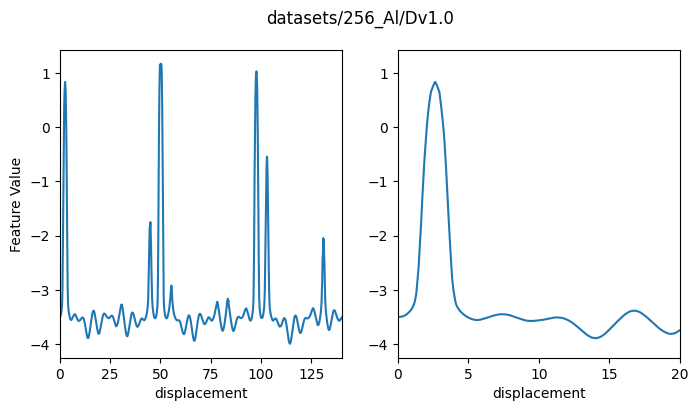

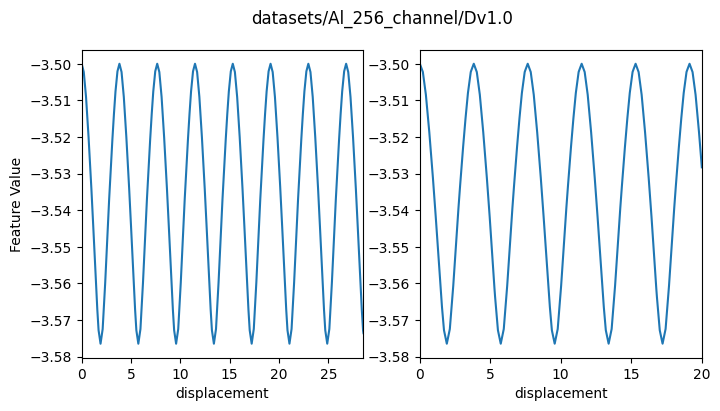

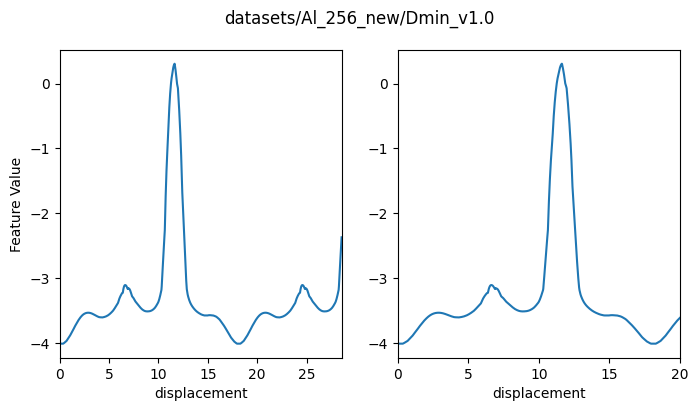

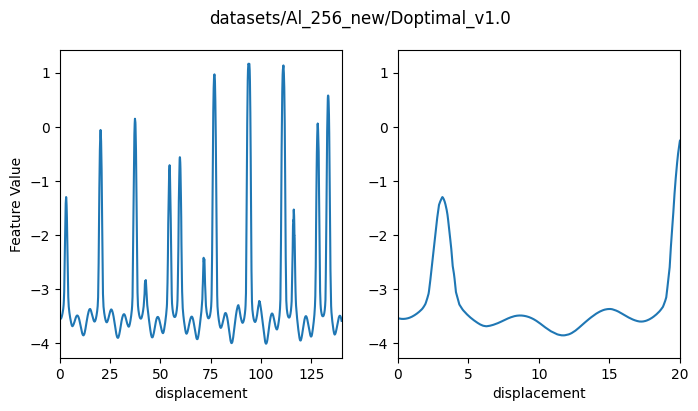

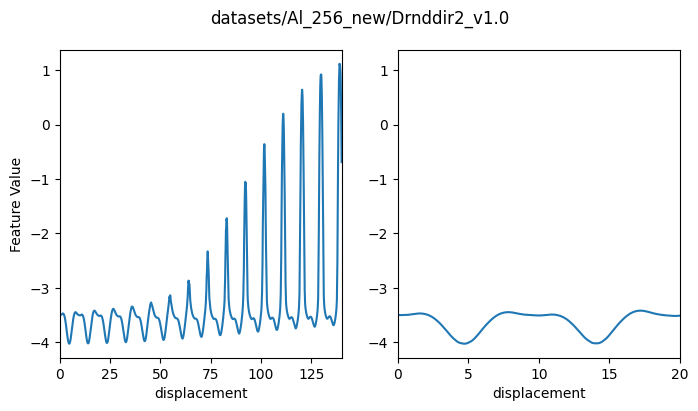

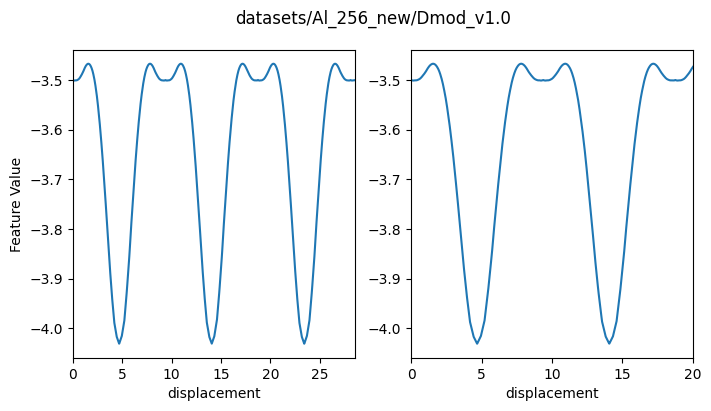

In [10]:
for directory in data_v1['directory'].unique():

    subset = data[data['directory'] == directory]
    fig, ax = plt.subplots(1, 2)
    feature = charge_features
    labels = feature.feature_labels()
    ax[0].plot(subset['displacement'], subset[labels], '-', label=labels)
    ax[1].plot(subset['displacement'], subset[labels])

    #ax.legend(labels)
    ax[0].set_xlim(0, subset['displacement'].max())
    #ax[0].set_ylim(0, 1.5)
    ax[1].set_xlim(0, 20)
    for a in ax:
        a.set_xlabel('displacement')
    ax[0].set_ylabel('Feature Value')
    fig.set_size_inches(8, 4)
    fig.suptitle(directory, fontsize=12)

## Compute AGNI Fingerprints
Use these to describe the local enviroment around a particle

In [11]:
agni_features = ProjectedAGNIFingerprints(start_frame, etas=np.logspace(np.log10(0.8), np.log10(16), 8).tolist(),
                                          use_prim_cell=False)

2025-07-30 14:05:58 - splitted atom


30.623800 0.000000 0.000000
0.000000 30.623800 0.000000
0.000000 0.000000 30.623800
Al 11.48393195 11.48393195 7.65595463
Al 11.48393195 7.65595463 11.48393195
Al 7.65595463 11.48393195 11.48393195
Al 7.65595463 7.65595463 7.65595463
Al 11.48393195 11.48393195 0.00000000
Al 11.48393195 7.65595463 3.82797732
Al 7.65595463 11.48393195 3.82797732
Al 7.65595463 7.65595463 0.00000000
Al 11.48393195 3.82797732 7.65595463
Al 11.48393195 0.00000000 11.48393195
Al 7.65595463 3.82797732 11.48393195
Al 7.65595463 0.00000000 7.65595463
Al 11.48393195 3.82797732 0.00000000
Al 11.48393195 0.00000000 3.82797732
Al 7.65595463 3.82797732 3.82797732
Al 7.65595463 0.00000000 0.00000000
Al 3.82797732 11.48393195 7.65595463
Al 3.82797732 7.65595463 11.48393195
Al 0.00000000 11.48393195 11.48393195
Al 0.00000000 7.65595463 7.65595463
Al 3.82797732 11.48393195 0.00000000
Al 3.82797732 7.65595463 3.82797732
Al 0.00000000 11.48393195 3.82797732
Al 0.00000000 7.65595463 0.00000000
Al 3.82797732 3.82797732 7.655

In [12]:
%%time
data = compute_features(agni_features, data) 

Start featurizing: Wed Jul 30 14:05:59 2025


ProjectedAGNIFingerprints: 100%|██████████| 82569/82569 [00:19<00:00, 4280.29it/s]


Done featurizing: Wed Jul 30 14:06:20 2025
CPU times: user 4.2 s, sys: 9.28 s, total: 13.5 s
Wall time: 21 s


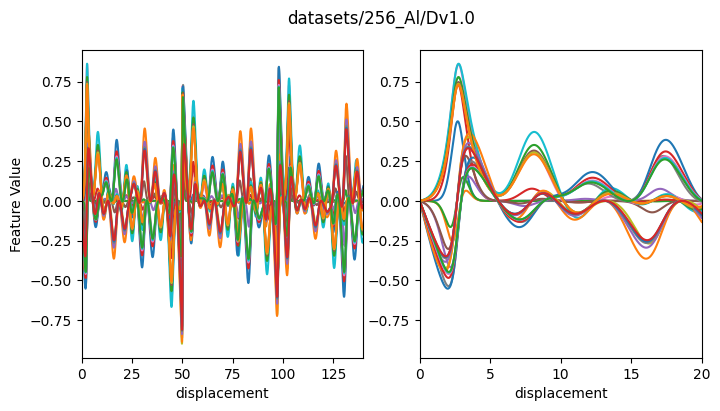

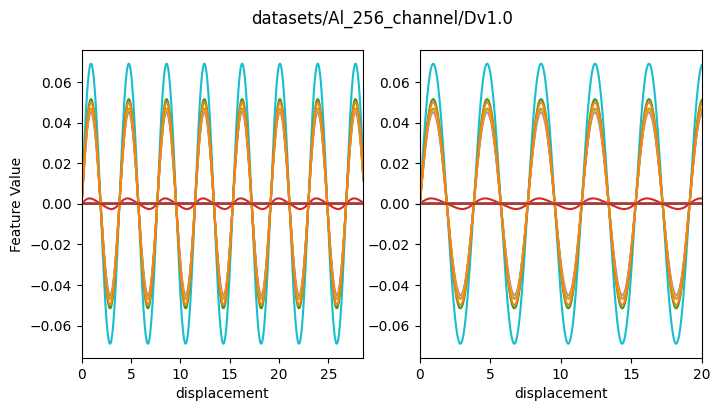

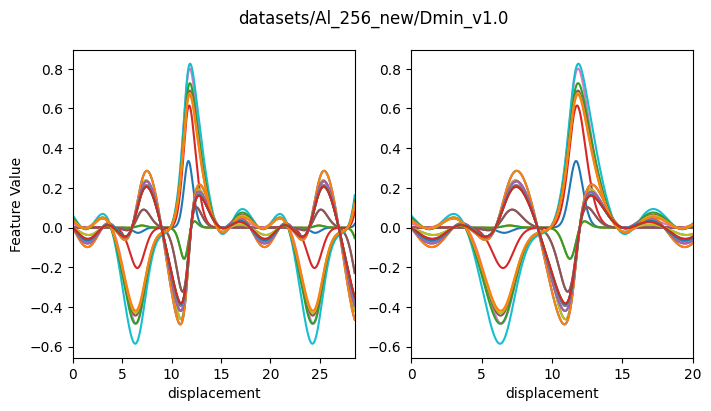

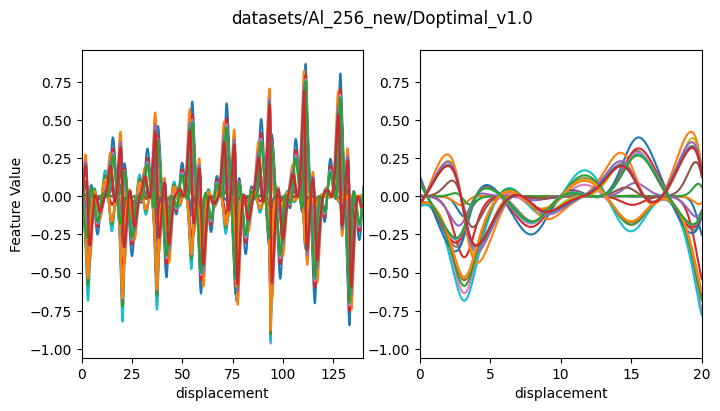

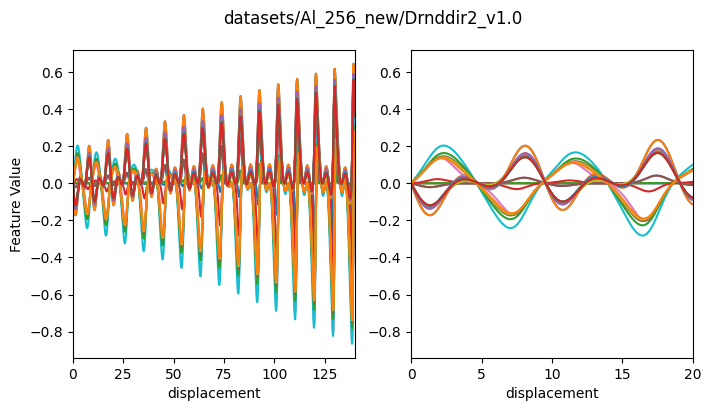

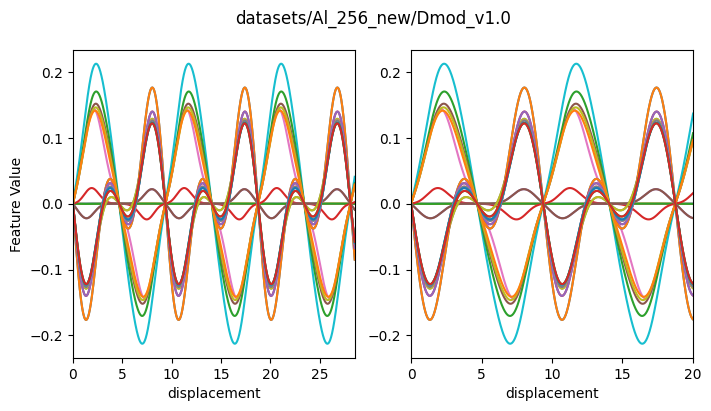

In [13]:
for directory in data_v1['directory'].unique():

    subset = data[data['directory'] == directory]
    fig, ax = plt.subplots(1, 2)
    feature = agni_features
    labels = feature.feature_labels()
    ax[0].plot(subset['displacement'], subset[labels], '-', label=labels)
    ax[1].plot(subset['displacement'], subset[labels])

    #ax.legend(labels)
    ax[0].set_xlim(0, subset['displacement'].max())
    #ax[0].set_ylim(0, 1.5)
    ax[1].set_xlim(0, 20)
    for a in ax:
        a.set_xlabel('displacement')
    ax[0].set_ylabel('Feature Value')
    fig.set_size_inches(8, 4)
    fig.suptitle(directory, fontsize=12)

In [14]:
nan_rows = data[data.isna().any(axis=1)]
display(nan_rows) 


,frame_id,force,position,velocity,energy,file_id,file,timestep,displacement,directory,...,AGNI_z in Al eta=4.43e+00,AGNI_x in Al eta=6.80e+00,AGNI_y in Al eta=6.80e+00,AGNI_z in Al eta=6.80e+00,AGNI_x in Al eta=1.04e+01,AGNI_y in Al eta=1.04e+01,AGNI_z in Al eta=1.04e+01,AGNI_x in Al eta=1.60e+01,AGNI_y in Al eta=1.60e+01,AGNI_z in Al eta=1.60e+01


## Compute Ion-Ion Interaction Forces
Get the repulsion force due to the ion-ion repulsion from the surrounding Al nuclei. Specifically, we compute the force acting on the particle in the direction of travel using the [Ewald summation method](https://en.wikipedia.org/wiki/Ewald_summation).

In [15]:
ewald_features = IonIonForce(start_frame, acc=4, flatten=False)

In [16]:
%%time
data = compute_features(ewald_features, data) 

Start featurizing: Wed Jul 30 14:06:22 2025


IonIonForce: 100%|██████████| 82569/82569 [00:38<00:00, 2133.98it/s]


Done featurizing: Wed Jul 30 14:07:02 2025
CPU times: user 1.97 s, sys: 8.66 s, total: 10.6 s
Wall time: 40.3 s


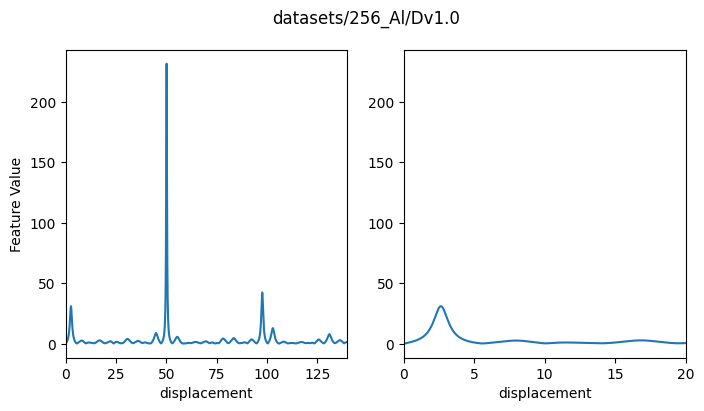

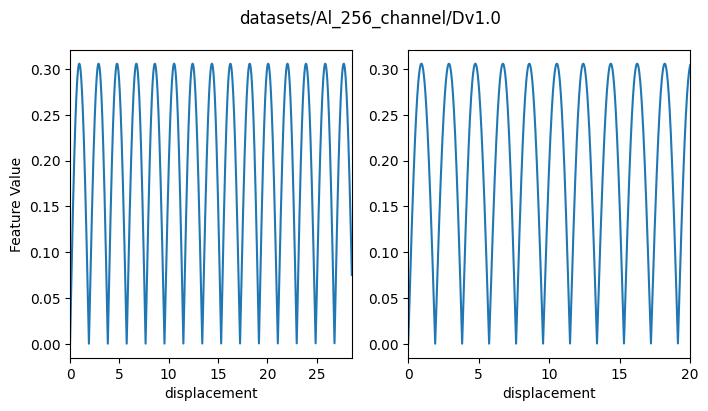

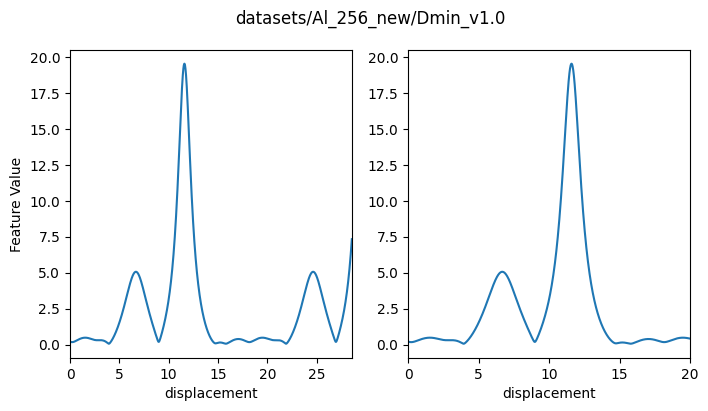

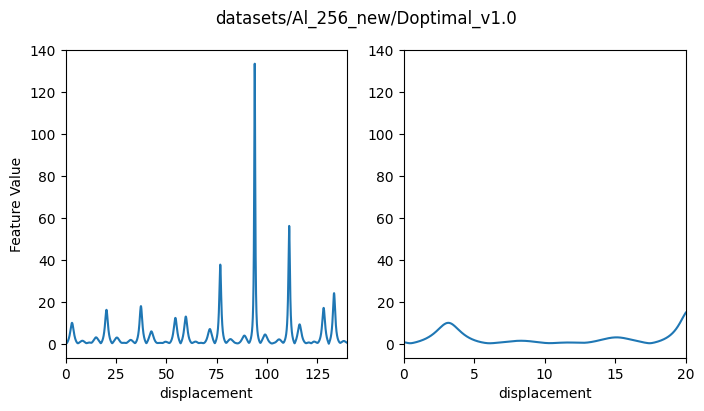

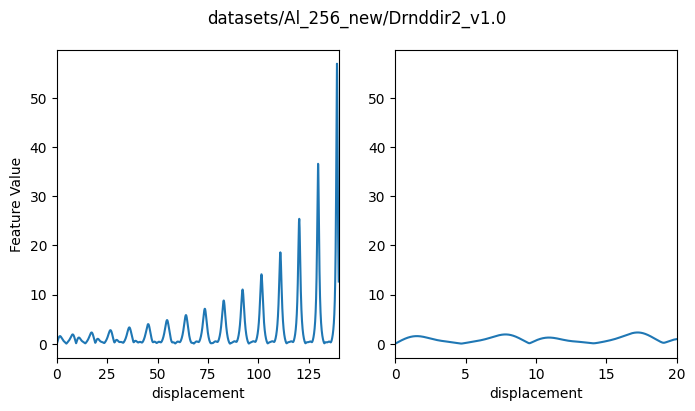

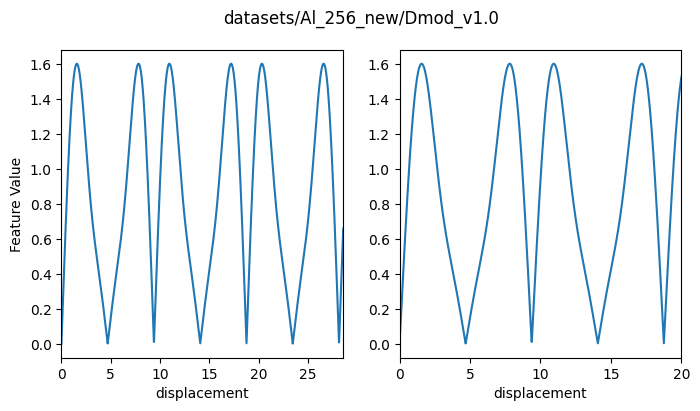

In [17]:
for directory in data_v1['directory'].unique():

    subset = data[data['directory'] == directory]
    fig, ax = plt.subplots(1, 2)
    feature = ewald_features
    labels = feature.feature_labels()
    ax[0].plot(subset['displacement'], subset[labels], '-', label=labels)
    ax[1].plot(subset['displacement'], subset[labels])

    #ax.legend(labels)
    ax[0].set_xlim(0, subset['displacement'].max())
    #ax[0].set_ylim(0, 1.5)
    ax[1].set_xlim(0, 20)
    for a in ax:
        a.set_xlabel('displacement')
    ax[0].set_ylabel('Feature Value')
    fig.set_size_inches(8, 4)
    fig.suptitle(directory, fontsize=12)

## Compute closest atoms
Use these to describe the distance to n closest atoms to a particle

In [18]:
atom_features = ClosestAtomsDistances(simulation_cell=start_frame,  n_closest=2, coulombic=False)

In [19]:
data = compute_features(atom_features, data)

Start featurizing: Wed Jul 30 14:07:29 2025


ClosestAtomsDistances: 100%|██████████| 82569/82569 [01:40<00:00, 821.71it/s] 


Done featurizing: Wed Jul 30 14:09:28 2025


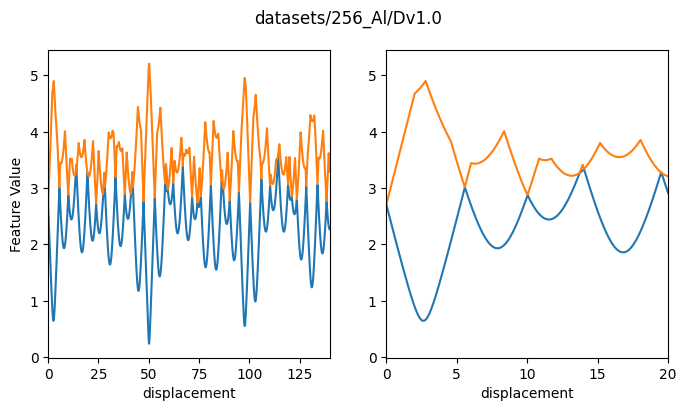

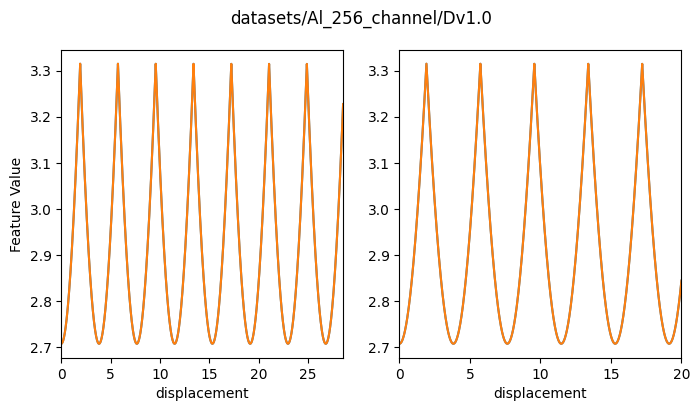

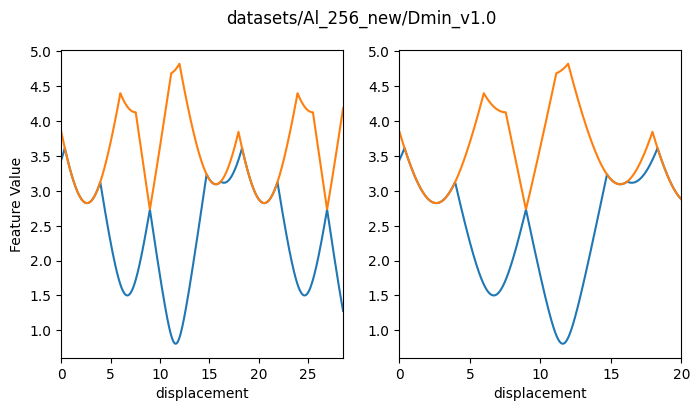

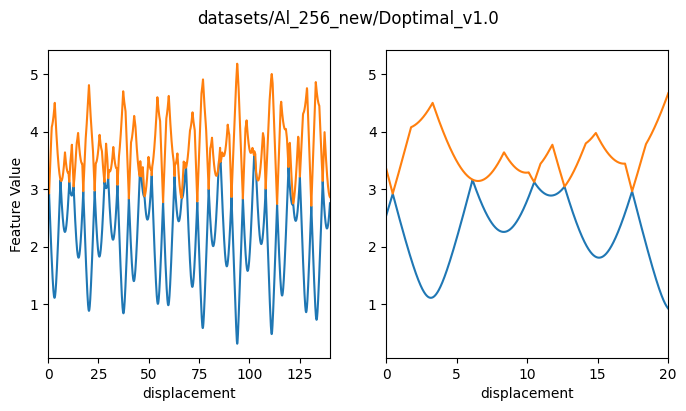

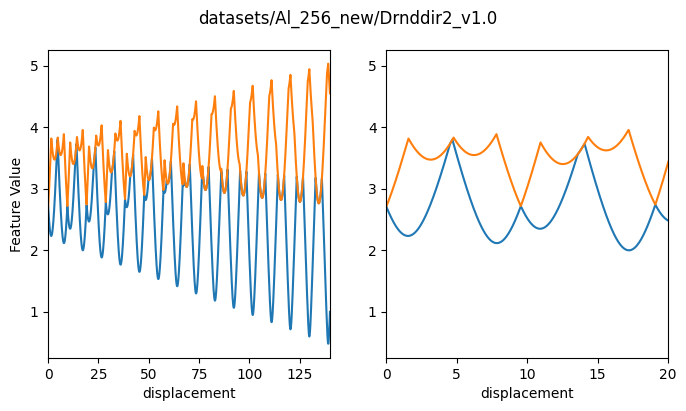

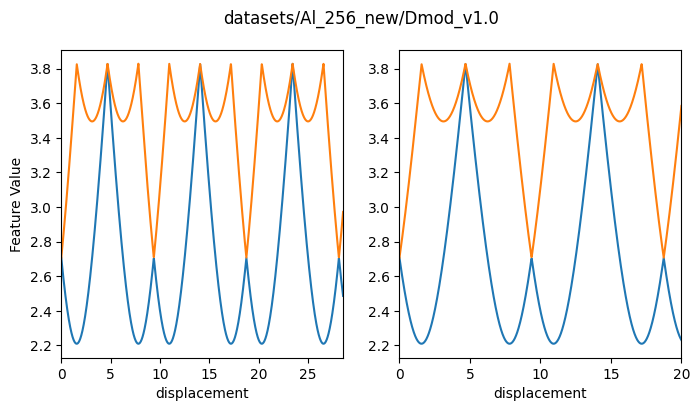

In [20]:
for directory in data_v1['directory'].unique():

    subset = data[data['directory'] == directory]
    fig, ax = plt.subplots(1, 2)
    feature = atom_features
    labels = feature.feature_labels()
    ax[0].plot(subset['displacement'], subset[labels], '-', label=labels)
    ax[1].plot(subset['displacement'], subset[labels])

    # ax.legend(labels)
    ax[0].set_xlim(0, subset['displacement'].max())
    #ax[0].set_ylim(0, 1.5)
    ax[1].set_xlim(0, 20)
    for a in ax:
        a.set_xlabel('displacement')
    ax[0].set_ylabel('Feature Value')
    fig.set_size_inches(8, 4)
    fig.suptitle(directory, fontsize=12)

In [21]:
nan_rows = data[data.isna().any(axis=1)]
display(nan_rows) 


,frame_id,force,position,velocity,energy,file_id,file,timestep,displacement,directory,...,AGNI_z in Al eta=6.80e+00,AGNI_x in Al eta=1.04e+01,AGNI_y in Al eta=1.04e+01,AGNI_z in Al eta=1.04e+01,AGNI_x in Al eta=1.60e+01,AGNI_y in Al eta=1.60e+01,AGNI_z in Al eta=1.60e+01,ion-ion repulsion,distance_to_atom_0,distance_to_atom_1


## Add Velocity as Feature
Just the magnitude of the projectile velocity

In [22]:
velocity_feature = ProjectileVelocity(start_frame)

In [23]:
# %%time
# data = compute_features(velocity_feature, data) 

## Add Displacement as Feature [ENERGY]
Just the magnitude of the projectile displacement

In [24]:
displacement_feature = ProjectileDisplacement(start_frame)

## Make a MultiFeaturizer
Will enable computing features in parallel slightly faster.

Also, for this project, we're going to skip the velocity feature

In [25]:
featurizer = MultipleFeaturizer([charge_features, atom_features, ewald_features, agni_features])
#  agni_features, ewald_features

In [26]:
featurizer

MultipleFeaturizer(featurizers=[PositionOffset(featurizer=LocalChargeDensity(charge=<scipy.interpolate._rgi.RegularGridInterpolator object at 0x7f8737971e50>,
                                                                             simulation_cell=Structure Summary
Lattice
    abc : 30.6238 30.6238 30.6238
 angles : 90.0 90.0 90.0
 volume : 28719.52411667327
      A : 30.6238 0.0 0.0
      B : 0.0 30.6238 0.0
      C : 0.0 0.0 30.6238
    pbc : True True True
PeriodicSite: Al (11.48, 11.48...
PeriodicSite: Al (19.14, 15.31, 26.8) [0.625, 0.5, 0.875]
PeriodicSite: Al (15.31, 19.14, 26.8) [0.5, 0.625, 0.875]
PeriodicSite: Al (15.31, 15.31, 22.97) [0.5, 0.5, 0.75]
PeriodicSite: Al (19.14, 19.14, 15.31) [0.625, 0.625, 0.5]
PeriodicSite: Al (19.14, 15.31, 19.14) [0.625, 0.5, 0.625]
PeriodicSite: Al (15.31, 19.14, 19.14) [0.5, 0.625, 0.625]
PeriodicSite: Al (15.31, 15.31, 15.31) [0.5, 0.5, 0.5])])

## Save everything to disk
Data and featurizers

In [27]:
data.to_pickle(gzip.open('training_data_0_2_atom_ion_mag.pkl.gz', 'wb'))

In [28]:
pkl.dump(featurizer, open('featurizers_0_2_atoms_ion_mag.pkl', 'wb'))